In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
import shap
import joblib

In [4]:
# Load Data:

df = pd.read_csv("../data/train.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
# Size of the data
print(f"Data Size: {df.shape}")

Data Size: (45593, 20)


In [4]:
# Data Exploration:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [5]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [6]:
(df == "NaN ").sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

Let's convert this string "NaN " to actual null values so we can handle them better way.

In [7]:
# Replace "NaN " values:
df = df.replace(["NaN ", "NaN","NAN", "nan","Nan"], np.nan)
(df == "NaN ").sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [8]:
# Let's check if we got null values or not
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [9]:
# Rename the Weatherconditions column:
df = df.rename(columns={"Weatherconditions": "Weather_conditions"})
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## Extract Features:

In [10]:
# Weather_conditions
df["Weather_conditions"] = df["Weather_conditions"].apply(lambda x : x.split(" ")[1])

# Time taken
df["Time_taken(min)"] = df["Time_taken(min)"].apply(lambda x : x.split(" ")[1])
 
# Extract City using Delivery Person ID
df["City_name"] = df["Delivery_person_ID"].apply(lambda x : x.split("RE")[0])

In [11]:
# There is already one column named City which is denoting type of the city so let's change it
df.rename(columns={"City" : "City_type"}, inplace=True)

In [12]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,INDO
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,BANG
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,BANG
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,COIMB
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,CHEN


In [13]:
# Removing ID & Person ID column now as it's not important for our model
df = df.drop(["ID", "Delivery_person_ID"], axis = 1)

In [14]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name
0,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,INDO
1,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,BANG
2,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,BANG
3,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,COIMB
4,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,CHEN


In [15]:
df["Weather_conditions"].unique() # One "NaN" String we missed because of the space let's replace it too

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN'],
      dtype=object)

In [16]:
df["Weather_conditions"] = df["Weather_conditions"].replace("NaN", np.nan)
df.isnull().sum()

Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City_type                      1200
Time_taken(min)                   0
City_name                         0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          43739 non-null  object 
 1   Delivery_person_Ratings      43685 non-null  object 
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Order_Date                   45593 non-null  object 
 7   Time_Orderd                  43862 non-null  object 
 8   Time_Order_picked            45593 non-null  object 
 9   Weather_conditions           44977 non-null  object 
 10  Road_traffic_density         44992 non-null  object 
 11  Vehicle_condition            45593 non-null  int64  
 12  Type_of_order                45593 non-null  object 
 13  Type_of_vehicle 

In [18]:
# Convert columns to thier suitable data type
df["Delivery_person_Age"] = df["Delivery_person_Age"].astype(float)
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].astype(float)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"],format="%H:%M:%S",errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"],format="%H:%M:%S",errors="coerce")
df["multiple_deliveries"] = df["multiple_deliveries"].astype(float)
df["Time_taken(min)"] = df["Time_taken(min)"].astype(float)

df.dtypes

Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Orderd                    datetime64[ns]
Time_Order_picked              datetime64[ns]
Weather_conditions                     object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City_type                              object
Time_taken(min)                       float64
City_name                              object
dtype: object

In [19]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,INDO
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,BANG
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,BANG
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,COIMB
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,CHEN


## Handelling Date & Time Columns:

As we can't use Datetime columns directly in model training we can extract useful data from those columns such as order_hour, pickup hour, order_weekday and order_minute

In [20]:
df["order_hour"] = df["Time_Orderd"].dt.hour # Extracting just hour of order
df["order_weekday"] = df["Order_Date"].dt.weekday # The day on which order took place
df["pickup_hour"] = df["Time_Order_picked"].dt.hour # Hour of order pickup

# Drop Original Columns (No need)
df = df.drop(["Time_Orderd", "Order_Date", "Time_Order_picked"], axis = 1)

df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,INDO,11.0,5,11
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,BANG,19.0,4,19
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,BANG,8.0,5,8
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,COIMB,18.0,1,18
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,CHEN,13.0,5,13


In [21]:
# Check now if any object or datetime data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          43739 non-null  float64
 1   Delivery_person_Ratings      43685 non-null  float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weather_conditions           44977 non-null  object 
 7   Road_traffic_density         44992 non-null  object 
 8   Vehicle_condition            45593 non-null  int64  
 9   Type_of_order                45593 non-null  object 
 10  Type_of_vehicle              45593 non-null  object 
 11  multiple_deliveries          44600 non-null  float64
 12  Festival                     45365 non-null  object 
 13  City_type       

In [22]:
df.isnull().sum()

Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City_type                      1200
Time_taken(min)                   0
City_name                         0
order_hour                     1731
order_weekday                     0
pickup_hour                       0
dtype: int64

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

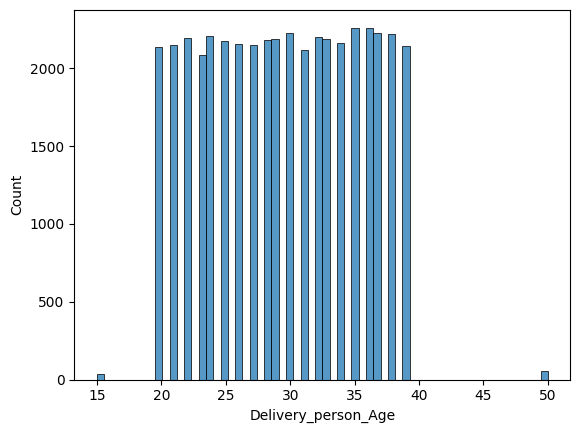

In [23]:
sns.histplot(data=df,x="Delivery_person_Age")

In [24]:
df.corr(numeric_only=True)["Time_taken(min)"]

Delivery_person_Age            0.299474
Delivery_person_Ratings       -0.338790
Restaurant_latitude            0.013981
Restaurant_longitude           0.007821
Delivery_location_latitude     0.014243
Delivery_location_longitude    0.007625
Vehicle_condition             -0.234398
multiple_deliveries            0.387051
Time_taken(min)                1.000000
order_hour                     0.184378
order_weekday                  0.007100
pickup_hour                    0.202323
Name: Time_taken(min), dtype: float64

## Handeling Null Values:

In [25]:
df.isnull().sum()

Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City_type                      1200
Time_taken(min)                   0
City_name                         0
order_hour                     1731
order_weekday                     0
pickup_hour                       0
dtype: int64

In [26]:
# Age -> Numerical -> Replace with median
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
df.iloc[[42,74]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
42,30.0,NaN,19.121999,72.908493,19.201999,72.988493,Cloudy,Medium,1,Drinks,scooter,1.0,No,Metropolitian,33.0,MUM,NaN,2,18
74,30.0,NaN,12.935662,77.614130,12.975662,77.654130,NaN,NaN,1,Drinks,scooter,0.0,No,Metropolitian,19.0,BANG,NaN,4,15


In [27]:
# Ratings -> Numerical -> Replace with median

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())
df.iloc[[42,74]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
42,30.0,4.7,19.121999,72.908493,19.201999,72.988493,Cloudy,Medium,1,Drinks,scooter,1.0,No,Metropolitian,33.0,MUM,NaN,2,18
74,30.0,4.7,12.935662,77.614130,12.975662,77.654130,NaN,NaN,1,Drinks,scooter,0.0,No,Metropolitian,19.0,BANG,NaN,4,15


In [28]:
df[df["Road_traffic_density"].isnull()].head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
74,30.0,4.7,12.935662,77.614130,12.975662,77.654130,NaN,NaN,1,Drinks,scooter,0.0,No,Metropolitian,19.0,BANG,NaN,4,15
120,30.0,4.7,22.312790,73.170283,22.422790,73.280283,NaN,NaN,3,Snack,electric_scooter,0.0,No,Metropolitian,25.0,VAD,NaN,5,18
250,30.0,4.7,18.536718,73.830327,18.646718,73.940327,NaN,NaN,3,Buffet,motorcycle,1.0,Yes,Urban,43.0,PUNE,NaN,1,21
348,30.0,4.7,12.935662,77.614130,13.065662,77.744130,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,26.0,BANG,NaN,2,0
425,30.0,4.7,-30.366322,-78.070453,30.496322,78.200453,NaN,NaN,3,Snack,scooter,1.0,No,Metropolitian,20.0,DEH,NaN,4,22


In [29]:
# Weather Conditions-> Categorical -> Replace with mode (Most freq)
df["Weather_conditions"] = df["Weather_conditions"].fillna(df["Weather_conditions"].mode()[0]) 
df.iloc[[74,120]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
74,30.0,4.7,12.935662,77.614130,12.975662,77.654130,Fog,NaN,1,Drinks,scooter,0.0,No,Metropolitian,19.0,BANG,NaN,4,15
120,30.0,4.7,22.312790,73.170283,22.422790,73.280283,Fog,NaN,3,Snack,electric_scooter,0.0,No,Metropolitian,25.0,VAD,NaN,5,18


In [30]:
# Road Traffic Density -> Categorical -> Replace with mode (Most freq)
df["Road_traffic_density"] = df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0]) 
df.iloc[[74,120]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
74,30.0,4.7,12.935662,77.614130,12.975662,77.654130,Fog,Low,1,Drinks,scooter,0.0,No,Metropolitian,19.0,BANG,NaN,4,15
120,30.0,4.7,22.312790,73.170283,22.422790,73.280283,Fog,Low,3,Snack,electric_scooter,0.0,No,Metropolitian,25.0,VAD,NaN,5,18


In [31]:
df[df["multiple_deliveries"].isnull()].head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
17,34.0,4.9,17.426228,78.407495,17.496228,78.477495,Cloudy,Jam,0,Snack,motorcycle,NaN,No,Metropolitian,41.0,HYD,20.0,6,20
86,39.0,4.8,18.516216,73.842527,18.566216,73.892527,Stormy,Jam,1,Meal,motorcycle,NaN,No,Metropolitian,28.0,PUNE,21.0,3,22
95,25.0,5.0,21.160437,72.774209,21.270437,72.884209,Stormy,Jam,1,Meal,motorcycle,NaN,No,Metropolitian,15.0,SUR,20.0,4,20
135,28.0,4.8,12.939496,77.625999,12.989496,77.675999,Fog,Low,1,Drinks,motorcycle,NaN,No,Metropolitian,18.0,BANG,23.0,3,23
144,29.0,4.6,21.171060,72.789292,21.251060,72.869292,Sunny,Jam,2,Meal,electric_scooter,NaN,No,Metropolitian,17.0,SUR,19.0,5,19


In [32]:
# Multiple Deliveries -> Categorical -> Replace with mode (Most freq)
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].mode()[0]) 
df.iloc[[17,86]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
17,34.0,4.9,17.426228,78.407495,17.496228,78.477495,Cloudy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,41.0,HYD,20.0,6,20
86,39.0,4.8,18.516216,73.842527,18.566216,73.892527,Stormy,Jam,1,Meal,motorcycle,1.0,No,Metropolitian,28.0,PUNE,21.0,3,22


In [33]:
df[df["Festival"].isnull()].head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
1401,30.0,4.9,23.235123,77.398886,23.255123,77.418886,Sunny,Low,2,Drinks,scooter,1.0,NaN,Metropolitian,12.0,BHP,9.0,3,9
1406,30.0,4.7,22.745536,75.893106,22.765536,75.913106,Cloudy,Low,2,Meal,electric_scooter,0.0,NaN,Metropolitian,10.0,INDO,NaN,2,8
1415,24.0,4.5,13.091809,80.219104,13.101809,80.229104,Sandstorms,Low,2,Drinks,motorcycle,0.0,NaN,Urban,11.0,CHEN,9.0,1,9
1586,25.0,4.6,11.022169,76.999594,11.132169,77.109594,Stormy,Low,2,Meal,scooter,1.0,NaN,Metropolitian,14.0,COIMB,22.0,5,22
1623,29.0,4.9,17.450851,78.379347,17.470851,78.399347,Windy,Low,2,Snack,motorcycle,0.0,NaN,Metropolitian,13.0,HYD,9.0,1,9


In [34]:
# City_type -> Categorical -> Replace with mode (Most freq)
df["City_type"] = df["City_type"].fillna(df["City_type"].mode()[0])

In [35]:
# Festival -> Categorical -> Replace with mode (Most freq)
df["Festival"] = df["Festival"].fillna(df["Festival"].mode()[0]) 
df.iloc[[1401,1406]]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
1401,30.0,4.9,23.235123,77.398886,23.255123,77.418886,Sunny,Low,2,Drinks,scooter,1.0,No,Metropolitian,12.0,BHP,9.0,3,9
1406,30.0,4.7,22.745536,75.893106,22.765536,75.913106,Cloudy,Low,2,Meal,electric_scooter,0.0,No,Metropolitian,10.0,INDO,NaN,2,8


In [36]:
# Now Tricky one which is Time_Orderd -> Can't replace with mean or median 

df["order_hour"].isnull().mean()*100 

3.7966354484241003

As it is less than 5% of the data we can simply remove those rows.

In [37]:
print(f"Before dropping Null values : {df.shape}")

Before dropping Null values : (45593, 19)


In [38]:
df = df.dropna(subset=["order_hour"]) # Dropping all rows with Null Time_Orderd values

In [39]:
print(f"After dropping Null values : {df.shape}")

After dropping Null values : (43862, 19)


In [40]:
# We handelled all null values perfectly
df.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City_type                      0
Time_taken(min)                0
City_name                      0
order_hour                     0
order_weekday                  0
pickup_hour                    0
dtype: int64

In [41]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,INDO,11.0,5,11
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,BANG,19.0,4,19
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,BANG,8.0,5,8
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,COIMB,18.0,1,18
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,CHEN,13.0,5,13


## Handeling Duplicate values:

In [42]:
df.duplicated().value_counts()

False    43862
Name: count, dtype: int64

No Duplicate value present 

## Feature Engineering:

Deriving New feature called Distance(km) using longitude and latitude data. For that we will use 

### Haversine Distance Formula:

![Haversine Formula](Haversine.png)

In [7]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2, radius=6371):
    """
    Vectorized Haversine distance.
    
    Parameters:
    lat1, lon1, lat2, lon2 : array-like (same shape or broadcastable)
        Latitudes and longitudes in degrees.
    radius : float
        Earth radius (6371 km, 3959 miles, or 6371000 meters)
    
    Returns:
    distances : numpy array
    """
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return radius * c

In [44]:
# Let's use this function into lat, lon rows
df["Distance(km)"] = haversine_distance(df["Restaurant_latitude"], df["Restaurant_longitude"], df["Delivery_location_latitude"], df["Delivery_location_longitude"])
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour,Distance(km)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,INDO,11.0,5,11,3.025149
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,BANG,19.0,4,19,20.183530
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,BANG,8.0,5,8,1.552758
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,COIMB,18.0,1,18,7.790401
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,CHEN,13.0,5,13,6.210138


In [45]:
df.corr(numeric_only=True)["Time_taken(min)"]

Delivery_person_Age            0.303010
Delivery_person_Ratings       -0.359726
Restaurant_latitude            0.015252
Restaurant_longitude           0.008110
Delivery_location_latitude     0.014824
Delivery_location_longitude    0.008668
Vehicle_condition             -0.243111
multiple_deliveries            0.379204
Time_taken(min)                1.000000
order_hour                     0.184378
order_weekday                  0.006505
pickup_hour                    0.202963
Distance(km)                  -0.001548
Name: Time_taken(min), dtype: float64

Why is the Distance Correlation value is so small?? Let's check it closely

In [46]:
df["Distance(km)"].describe()

count    43862.000000
mean        27.170206
std        303.076394
min          1.465067
25%          4.663432
50%          9.220419
75%         13.682165
max       6884.726399
Name: Distance(km), dtype: float64

As we can see max distance is way higher for in city deliveries they must be outliers

## Removing Outliers:

Let's check for outliers in each column

In [47]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min),order_hour,order_weekday,pickup_hour,Distance(km)
count,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000,43862.000000
mean,29.557179,4.635682,17.241971,70.764932,17.462466,70.828527,1.000889,0.749624,26.293831,17.423966,3.000137,17.151270,27.170206
std,5.747493,0.312907,7.698686,21.136195,7.338540,21.136365,0.816557,0.567594,9.373765,4.817856,1.970115,5.318761,303.076394
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,1.465067
25%,25.000000,4.500000,12.933298,73.170283,12.986229,73.279312,0.000000,0.000000,19.000000,15.000000,1.000000,14.000000,4.663432
50%,30.000000,4.700000,18.554382,75.898497,18.633934,75.999490,1.000000,1.000000,26.000000,19.000000,3.000000,19.000000,9.220419
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,2.000000,1.000000,32.000000,21.000000,5.000000,21.000000,13.682165
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,23.000000,6.000000,23.000000,6884.726399


In [48]:
df[df["Distance(km)"] >= 5000 ]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour,Distance(km)
92,34.0,4.7,-27.163303,78.057044,27.233303,78.127044,Sandstorms,Low,1,Drinks,scooter,0.0,No,Metropolitian,15.0,AGR,23.0,2,23,6048.631240
283,32.0,4.7,-27.165108,78.015053,27.225108,78.075053,Sandstorms,Jam,2,Meal,scooter,1.0,No,Metropolitian,31.0,AGR,20.0,6,21,6047.919478
1783,39.0,4.5,-23.230791,77.437020,23.250791,77.457020,Cloudy,Low,0,Meal,motorcycle,1.0,No,Metropolitian,29.0,BHP,9.0,6,9,5168.516553
1976,25.0,4.0,-22.539129,88.365507,22.549129,88.375507,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,19.0,KOL,9.0,1,9,5013.585658
2636,24.0,4.7,-30.902872,75.826808,30.972872,75.896808,Cloudy,Low,1,Meal,motorcycle,1.0,No,Urban,20.0,LUDH,22.0,5,22,6880.272782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40529,33.0,4.8,-26.470000,80.350000,26.520000,80.400000,Sunny,Jam,1,Meal,motorcycle,1.0,No,Metropolitian,17.0,KNP,19.0,1,19,5892.221596
40556,35.0,4.3,-25.443994,81.860187,25.473994,81.890187,Windy,Jam,2,Drinks,scooter,1.0,No,Metropolitian,32.0,ALH,20.0,6,20,5661.822858
41613,30.0,4.7,-22.538999,88.322337,22.598999,88.382337,Windy,Low,2,Drinks,scooter,0.0,No,Metropolitian,25.0,KOL,23.0,3,23,5019.120579
43643,30.0,4.8,-26.482581,80.315628,26.502581,80.335628,Sunny,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,10.0,KNP,10.0,1,11,5891.681591


These values for Distance are impossible to have. They must be error in data. Remove these outliers

Let's use IQR method to deal with these outlires

In [49]:
q1 = df["Distance(km)"].quantile(0.25)
q3 = df["Distance(km)"].quantile(0.75)

IQR = q3 - q1

q1, q3, IQR

(4.663432201620595, 13.682164589270348, 9.018732387649752)

In [50]:
# Find lower and upper bound

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR  # We only need upper for this case

lower, upper

(-8.864666379854032, 27.210263170744977)

In [51]:
df[df["Distance(km)"] > 30]["Distance(km)"].min() # Don't follow this outliers removing technique blindely check first. It can be real world outlier

2216.065793630105

In [52]:
print(f"Before Removing Outliers: {df.shape}")

Before Removing Outliers: (43862, 20)


In [53]:
# Remove values > upper bound

df = df[df["Distance(km)"] <= upper]

In [54]:
print(f"After Removing Outliers: {df.shape}")

After Removing Outliers: (43706, 20)


In [55]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min),order_hour,order_weekday,pickup_hour,Distance(km)
count,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000,43706.000000
mean,29.556972,4.635695,17.382243,70.735456,17.445844,70.799057,1.000709,0.749600,26.298151,17.423283,2.999062,17.150117,9.733727
std,5.748404,0.312948,7.335807,21.166164,7.337160,21.166338,0.816473,0.567745,9.376591,4.817890,1.970199,5.319350,5.604686
min,20.000000,2.500000,0.000000,0.000000,0.010000,0.010000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,1.465067
25%,25.000000,4.500000,12.934179,73.170283,12.985746,73.277753,0.000000,0.000000,19.000000,15.000000,1.000000,14.000000,4.663412
50%,30.000000,4.700000,18.554382,75.898497,18.632718,75.997648,1.000000,1.000000,26.000000,19.000000,3.000000,19.000000,9.220209
75%,35.000000,4.900000,22.732225,78.044095,22.783839,78.099903,2.000000,1.000000,32.000000,21.000000,5.000000,21.000000,13.681416
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,23.000000,6.000000,23.000000,20.969489


Let's check again if correlation with distance improved or not.

In [56]:
df.corr(numeric_only=True)["Time_taken(min)"]

Delivery_person_Age            0.303309
Delivery_person_Ratings       -0.359545
Restaurant_latitude            0.013569
Restaurant_longitude           0.008229
Delivery_location_latitude     0.015177
Delivery_location_longitude    0.008787
Vehicle_condition             -0.243006
multiple_deliveries            0.378975
Time_taken(min)                1.000000
order_hour                     0.184588
order_weekday                  0.006440
pickup_hour                    0.203079
Distance(km)                   0.322029
Name: Time_taken(min), dtype: float64

As we can see dist correlation improved from 0.00 -> 0.32

In [57]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),City_name,order_hour,order_weekday,pickup_hour,Distance(km)
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,INDO,11.0,5,11,3.025149
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,BANG,19.0,4,19,20.183530
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,BANG,8.0,5,8,1.552758
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,COIMB,18.0,1,18,7.790401
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,CHEN,13.0,5,13,6.210138


## Encoding:

Encoding columns which has non-numerical data, We will use:
- Label Encoding -> Ordinal Columns
- One-Hot Encoding -> Nominal Columns

In [58]:
# Nominal Columns -> Type_of_order, Type_of_vehicle, Weather_conditions, City

df = pd.get_dummies(data = df, columns=["Type_of_order", "Type_of_vehicle", "City_name", "Weather_conditions", "City_type"], drop_first=True)

df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,City_name_RANCHI,City_name_SUR,City_name_VAD,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,City_type_Semi-Urban,City_type_Urban
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,High,2,0.0,No,...,False,False,False,False,False,False,True,False,False,True
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Jam,2,1.0,No,...,False,False,False,False,False,True,False,False,False,False
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,Low,0,1.0,No,...,False,False,False,False,True,False,False,False,False,True
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,Medium,0,1.0,No,...,False,False,False,False,False,False,True,False,False,False
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,High,1,1.0,No,...,False,False,False,False,False,False,False,False,False,False


In [59]:
df["Road_traffic_density"].unique() # As we can see all valus has one space at the end

array(['High ', 'Jam ', 'Low ', 'Medium '], dtype=object)

In [60]:
df["Festival"].unique()

array(['No ', 'Yes '], dtype=object)

In [61]:
# Ordinal Column -> Road_traffic_density

traffic_map = {
    "Low " : 1,
    "Medium " : 2,
    "High " : 3,
    "Jam " : 4
}

df["Road_traffic_density"] = df["Road_traffic_density"].map(traffic_map)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,City_name_RANCHI,City_name_SUR,City_name_VAD,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,City_type_Semi-Urban,City_type_Urban
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,3,2,0.0,No,...,False,False,False,False,False,False,True,False,False,True
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,2,1.0,No,...,False,False,False,False,False,True,False,False,False,False
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,1,0,1.0,No,...,False,False,False,False,True,False,False,False,False,True
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2,0,1.0,No,...,False,False,False,False,False,False,True,False,False,False
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,3,1,1.0,No,...,False,False,False,False,False,False,False,False,False,False


In [62]:
# label Encoding -> Festival 

festival_map = {
    "Yes " : 1,
    "No " : 0
}

df["Festival"] = df["Festival"].map(festival_map)
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,City_name_RANCHI,City_name_SUR,City_name_VAD,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,City_type_Semi-Urban,City_type_Urban
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,3,2,0.0,0,...,False,False,False,False,False,False,True,False,False,True
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,2,1.0,0,...,False,False,False,False,False,True,False,False,False,False
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,1,0,1.0,0,...,False,False,False,False,True,False,False,False,False,True
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2,0,1.0,0,...,False,False,False,False,False,False,True,False,False,False
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,3,1,1.0,0,...,False,False,False,False,False,False,False,False,False,False


In [63]:
# Define X and y
X = df.drop("Time_taken(min)", axis = 1)
y = df["Time_taken(min)"]

X.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,City_name_RANCHI,City_name_SUR,City_name_VAD,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,City_type_Semi-Urban,City_type_Urban
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,3,2,0.0,0,...,False,False,False,False,False,False,True,False,False,True
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,4,2,1.0,0,...,False,False,False,False,False,True,False,False,False,False
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,1,0,1.0,0,...,False,False,False,False,True,False,False,False,False,True
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2,0,1.0,0,...,False,False,False,False,False,False,True,False,False,False
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,3,1,1.0,0,...,False,False,False,False,False,False,False,False,False,False


In [64]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((34964, 47), (8742, 47), (34964,), (8742,))

## Model Training:

If Overfitting -> Model is too complex -> Make simpler:
- reduce max_depth (Model is learning too much patterns)
- increase min_samples_leaf
- Add regularization

If Underfitting -> Model is too simple -> Make complex:
- Increase max_depth
- Increase n_estimators
- Reduce regularization

In [65]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Print train and test error

print(f"Train Score: {model.score(X_train, y_train)}")
print(f"Test Score: {model.score(X_test, y_test)}")

Train Score: 0.9759445882828178
Test Score: 0.826003016067903


As we can see here train score is better than test score means overfitting we need to tune hyperparametres to avoid this.

In [66]:
# Get y_pred
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate other metrics
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

MAE: 3.126712422786548
RMSE: 3.896781670765423


Calculate the gap between train and test error

- If gap > 20–30% of validation score → strong overfitting
- If gap < 10% → acceptable

In [67]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_rmse, test_rmse

(1.4556122389039277, 3.896781670765423)

In [68]:
# Calculte Overfitting gap
overfitting_gap = test_rmse - train_rmse
gap_pct = ((test_rmse - train_rmse)/test_rmse)*100
gap_pct

62.645784088334366

That is strong overfitting.

In [69]:
# Let's tune hyperparameters then
model = RandomForestRegressor(max_depth=25, min_samples_leaf=3, n_estimators=500, max_features='sqrt', random_state=42)
model.fit(X_train, y_train)

# Print train and test Score
print(f"Train Score: {model.score(X_train, y_train)}")
print(f"Test Score: {model.score(X_test, y_test)}")

Train Score: 0.8971952718677888
Test Score: 0.8011410422938141


In [70]:
# Let's Check Now Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance[:5])

                    Feature  Importance
1   Delivery_person_Ratings    0.157622
0       Delivery_person_Age    0.112882
6      Road_traffic_density    0.102543
13             Distance(km)    0.098225
8       multiple_deliveries    0.083836


In [71]:
# Let's try now XGBoost
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# Print train and test error
print(f"Train Score: {xgb_model.score(X_train, y_train)}")
print(f"Test Score: {xgb_model.score(X_test, y_test)}")

Train Score: 0.8715529186930256
Test Score: 0.824473058614823


As we can see that XGBoost giving better performance then Hypertuned RandomForest model so we will now use XGBoost.

Let's first cross validate XGBoost model so we can confidently say it's avg performance.

In [72]:
# Get cv_scores
cv_scores = cross_val_score(xgb_model, X_train, y_train, scoring= 'r2', cv=5)

# Let's check avg performance now 
print("Mean CV R2:", cv_scores.mean())

Mean CV R2: 0.8232229908440953


As we can see that it's giving consistent performance for all cross validates. Which indicates that it's a stable model. We are good to go!

## Mild Hyperperameter tuning of XGBoost model:

In [73]:
# Create base XGBoost model
xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Define Parmameter combination we want to use

param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Create Random Search object and give our model and this params
random_search = RandomizedSearchCV(
    estimator=xgb,                      # Model we want to tune (XGBoost)
    param_distributions=param_grid,     # Parameters we want to try
    n_iter=20,                          # Try 20 random Combinations
    scoring='r2',                       # Evaluate using r2 score
    cv=5,                               # use 5 fold cross validations
    verbose=1,                          # Show progress while running
    n_jobs=1,                           # Use all CPU cores (faster training)
    random_state=42
)

# Now train on this random_search object
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBRegressor(...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


It will:
1. Pick a random parameter combination
2. Train XGBoost
3. Do 5-fold cross validation
4. Calculate R²
5. Repeat 20 times
6. Save the best performing model

In [74]:
# Let's now print best performing model's parameters used & It's score
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV Score: 0.8235318562623931


Hyperparameter tuning using RandomizedSearchCV did not significantly improve model performance (CV R² ≈ 0.822). This suggests that the default XGBoost parameters were already well-suited for the dataset. Future improvements will focus on feature engineering and data preprocessing.

In [75]:
# Getting the best model
best_xgb = random_search.best_estimator_

# Predicting performance on test data
y_pred_xg = best_xgb.predict(X_test)

# Finding test and train score
print("Train R2:", best_xgb.score(X_train, y_train))
print("Test R2:", best_xgb.score(X_test, y_test))

Train R2: 0.8574895382139577
Test R2: 0.8252679965628371


Oh Actaully, Hyperparameter tuning slightly improved the test R² score while reducing the training score pretty well, indicating better generalization. The tuned XGBoost model is more stable and less prone to overfitting.

## Calculate Business Mertics (MAE & RMSE):

In [76]:
# Calculate MAE & RMSE
MAE = mean_absolute_error(y_test, y_pred_xg)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_xg))

# It will give us errors in minutes
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 3.154711494781801
RMSE: 3.905003629573772


On average, delivery time prediction error is ± 3.90 minutes.

## Feature Importance Analysis:

In [77]:
feature_importance = pd.Series(best_xgb.feature_importances_,
                       index=X_train.columns)

feature_importance.sort_values(ascending=False).head(10)

Road_traffic_density        0.143056
Weather_conditions_Sunny    0.140496
multiple_deliveries         0.127308
Delivery_person_Ratings     0.088664
Festival                    0.088297
Weather_conditions_Fog      0.081043
Vehicle_condition           0.067117
Delivery_person_Age         0.040251
Distance(km)                0.035483
City_type_Semi-Urban        0.028433
dtype: float32

### Analysis:
* So based on our feature importance analysis. We can say that road traffic density and multiple deliveries are the strongest predictors of delivery time.
* Weather conditions and delivery person ratings also significantly influence the model’s predictions.
* Interestingly, distance contributes less than expected, suggesting that traffic conditions may already capture route complexity.

 ## SHAP Analysis:

Now let's use SHAP to know contribution of each feature in a single prediction.

In [78]:
# Create SHAP explainer and give it our model to learn how our model works
explainer = shap.TreeExplainer(best_xgb) # Using TreeExplainer coz it's XGBoost model

# Calculate SHAP values for each test data
shap_values = explainer.shap_values(X_test) # Calculates contirbution of each feature in predicting each row

In [79]:
import xgboost
import shap

print(xgboost.__version__)
print(shap.__version__)

1.7.6
0.44.1


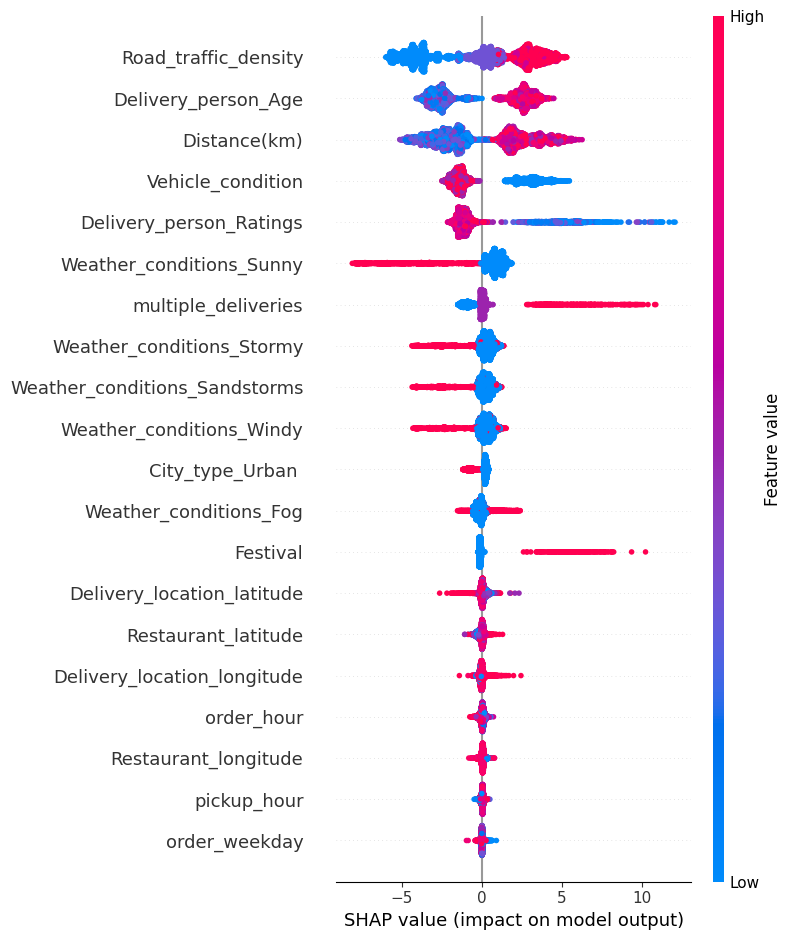

In [80]:
# Let's plot summary plot now
shap.summary_plot(shap_values, X_test)

### Based on this plot:
* SHAP analysis reveals that road traffic density is the strongest predictor.
* High traffic significantly increases delivery time, while low traffic reduces it.
* Distance also positively impacts delivery time.
* Higher delivery person ratings tend to reduce predicted delivery time.
* Adverse weather conditions and festivals contribute to longer delivery times.

Now let's see how each feature contributes prdicting a single value.

In [81]:
# Let's check for first row in test set
prediction = best_xgb.predict(X_test.iloc[[3]])
print("Predicted Delivery Time:", prediction[0])

Predicted Delivery Time: 35.058563


So our model has predicted delivery time as 24.59577 mins. Now let's check SHAP values for it.

In [82]:
shap_value_single = shap_values[3]
shap_value_single

array([ 2.7602565e+00, -6.2055534e-01, -1.6362050e-01,  3.1340636e-02,
        9.9791199e-02, -2.1185066e-01,  2.2101793e+00, -1.4979290e+00,
        6.4961257e+00, -2.2150098e-01, -9.6247375e-02,  5.3167198e-02,
        1.0254438e-01, -1.1797837e+00,  1.7374156e-02,  1.2640892e-01,
        9.8135304e-03,  7.2478570e-02, -3.7744075e-02, -3.8440034e-03,
       -3.2758701e-03,  9.8474417e-04,  1.8698446e-04,  1.7367650e-03,
        1.3859867e-03,  4.8372181e-04, -5.3091813e-04, -5.5821665e-04,
        6.7155128e-03,  5.2247860e-04, -1.6901693e-03, -6.0029165e-03,
        0.0000000e+00, -2.2400745e-04,  1.0291645e-02,  5.5534823e-04,
        2.4377488e-04,  3.1010837e-03,  3.7193648e-04,  9.8075895e-03,
        3.3365127e-02,  1.0806115e-01,  9.0812750e-02,  9.7388101e-01,
       -5.7339644e-01, -2.6824150e-02,  1.8112768e-01], dtype=float32)

To understand these values we need to plot Waterfall Chart.

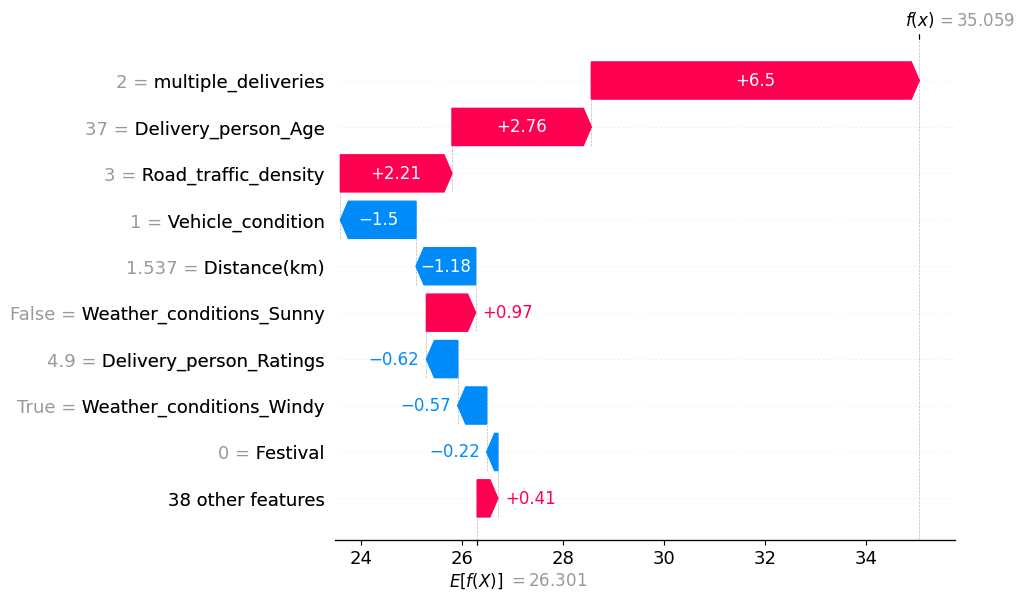

In [83]:
shap.plots.waterfall(shap.Explanation(
    values = shap_value_single,
    base_values=explainer.expected_value,
    data = X_test.iloc[3],
    feature_names= X_test.columns
))

So here for this specific order, the primary driver of increased delivery time was handling multiple deliveries, contributing approximately +6.25 minutes. Additionally, moderate traffic and higher delivery person age further increased the predicted time. However, short delivery distance, good vehicle condition, and high delivery person rating helped offset some delay.

# ==========================================
# FINAL PRODUCTION PIPELINE
# ==========================================

### Data Cleaning (Outside Pipeline):

In [2]:
df_final = pd.read_csv("train.csv")
df_final.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
df_final.shape

(45593, 20)

In [4]:
# Replacing NaN strings:
df_final = df_final.replace(["NaN ", "NaN","NAN", "nan","Nan"], np.nan)

# City Column renaming
df_final.rename(columns={"City" : "City_type"}, inplace=True)
df_final.rename(columns={"Weatherconditions": "Weather_conditions"}, inplace=True)

# Feature Extraction -> Permenent
df_final["Weather_conditions"] = df_final["Weather_conditions"].apply(lambda x : x.split(" ")[1])
df_final["Time_taken(min)"] = df_final["Time_taken(min)"].apply(lambda x : x.split(" ")[1])

# Type Conversion:
df_final["Delivery_person_Age"] = df_final["Delivery_person_Age"].astype(float)
df_final["Delivery_person_Ratings"] = df_final["Delivery_person_Ratings"].astype(float)
df_final["Order_Date"] = pd.to_datetime(df_final["Order_Date"], dayfirst=True)
df_final["Time_Orderd"] = pd.to_datetime(df_final["Time_Orderd"],format="%H:%M:%S",errors="coerce")
df_final["Time_Order_picked"] = pd.to_datetime(df_final["Time_Order_picked"],format="%H:%M:%S",errors="coerce")
df_final["multiple_deliveries"] = df_final["multiple_deliveries"].astype(float)
df_final["Time_taken(min)"] = df_final["Time_taken(min)"].astype(float)

In [5]:
df_final.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


In [8]:
# Calculate Distance Column
df_final["Distance(km)"] = haversine_distance(
            df_final["Restaurant_latitude"], df_final["Restaurant_longitude"],
            df_final["Delivery_location_latitude"], df_final["Delivery_location_longitude"]
        ) 

In [9]:
# No need of latitude and logitude columns now drop them
df_final = df_final.drop(columns = ["Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude", "Delivery_location_longitude"], axis = 1)

In [10]:
# We have outliers in Distance Column
df_final[df_final["Distance(km)"] >= 5000 ].head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),Distance(km)
92,0xc042,AGRRES010DEL01,34.0,4.7,2022-02-16,1900-01-01 23:00:00,1900-01-01 23:05:00,Sandstorms,Low,1,Drinks,scooter,0.0,No,Metropolitian,15.0,6048.631240
283,0xc044,AGRRES12DEL03,32.0,4.7,2022-02-13,1900-01-01 20:55:00,1900-01-01 21:10:00,Sandstorms,Jam,2,Meal,scooter,1.0,No,Metropolitian,31.0,6047.919478
289,0x4db,PUNERES02DEL03,NaN,NaN,2022-03-05,NaT,1900-01-01 22:05:00,Stormy,Jam,2,Meal,scooter,0.0,No,Urban,12.0,16612.239055
425,0xc003,DEHRES13DEL02,NaN,NaN,2022-02-18,NaT,1900-01-01 22:30:00,NaN,NaN,3,Snack,scooter,1.0,No,Metropolitian,20.0,17744.205087
534,0x473,MYSRES07DEL03,NaN,NaN,2022-03-03,NaT,1900-01-01 22:45:00,NaN,NaN,3,Buffet,scooter,NaN,No,Metropolitian,16.0,17118.828366


In [11]:
# Before remvoing outliers
df_final.shape

(45593, 17)

In [12]:
# Let't remove these outliers using IQR method
q1 = df_final["Distance(km)"].quantile(0.25)
q3 = df_final["Distance(km)"].quantile(0.75)

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR  # We only need upper for this case

df_final = df_final[df_final["Distance(km)"] <= upper]

In [13]:
# After remvoing outliers
df_final.shape

(45162, 17)

### Building Feature Engineering Class -> For Feature engineering of the columns

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Extract Features
        X["order_hour"] = X["Time_Orderd"].dt.hour # Extracting just hour of order
        X["order_weekday"] = X["Order_Date"].dt.weekday # The day on which order took place
        X["pickup_hour"] = X["Time_Order_picked"].dt.hour # Hour of order pickup

        # Dropping Unnecessary Columns
        X = X.drop(columns = ["Time_Orderd", "Order_Date", "Time_Order_picked", "Delivery_person_ID", "ID"], axis = 1, errors="ignore")

        return X

### Building Column Transformer -> For Handelling Null Values & Encoding

In [15]:
df_final.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_type,Time_taken(min),Distance(km)
0,0x4607,INDORES13DEL02,37.0,4.9,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,6.210138


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Distance(km)",
    "order_hour",
    "pickup_hour",
    "order_weekday",
    "multiple_deliveries",
    "Road_traffic_density",
]


categorical_features = [
    "Weather_conditions",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City_type",
]

# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Column Tranformation
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [17]:
# Let's use it with model and create final pipeline

final_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.1,
        colsample_bytree=0.9,
        random_state=42,
        subsample=1.0
    ))
])

In [18]:
# Drop rows where Time_Orderd is missing (since we cannot extract order_hour as it will be done inside pipeline)
df_final = df_final.dropna(subset=["Time_Orderd"])

In [19]:
# Map Traffic To Ordinal Numbers Before Splitting
traffic_map = {
    "Low ": 1,
    "Medium ": 2,
    "High ": 3,
    "Jam ": 4
}

df_final["Road_traffic_density"] = df_final["Road_traffic_density"].map(traffic_map)

### Train Pipeline 

In [20]:
# Create Train-Test split
X = df_final.drop("Time_taken(min)", axis = 1)
y = df_final["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Let's fit it into our pipeline so all the feature engineering and preprocessing(Handelling Null Values, Encoding) can be done internally
final_pipeline.fit(X_train, y_train)

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
print("Train R2:", final_pipeline.score(X_train, y_train))
print("Test R2:", final_pipeline.score(X_test, y_test))

Train R2: 0.817251087019826
Test R2: 0.7832360777109024


In [22]:
y_pred = final_pipeline.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 3.4598111666686147
RMSE: 4.349393629955839


In [23]:
df_final["Distance(km)"].describe()

count    43706.000000
mean         9.733727
std          5.604686
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681416
max         20.969489
Name: Distance(km), dtype: float64

### Let's save the model now

In [207]:
import joblib

joblib.dump(final_pipeline, "delivery_time_pipeline.pkl")

['delivery_time_pipeline.pkl']

In [212]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34964 entries, 35985 to 16455
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       34964 non-null  object        
 1   Delivery_person_ID       34964 non-null  object        
 2   Delivery_person_Age      34793 non-null  float64       
 3   Delivery_person_Ratings  34754 non-null  float64       
 4   Order_Date               34964 non-null  datetime64[ns]
 5   Time_Orderd              34964 non-null  datetime64[ns]
 6   Time_Order_picked        34964 non-null  datetime64[ns]
 7   Weather_conditions       34964 non-null  object        
 8   Road_traffic_density     34964 non-null  int64         
 9   Vehicle_condition        34964 non-null  int64         
 10  Type_of_order            34964 non-null  object        
 11  Type_of_vehicle          34964 non-null  object        
 12  multiple_deliveries      34232 no

In [224]:
df_final.iloc[2]

ID                                     0x5d6d 
Delivery_person_ID             BANGRES19DEL01 
Delivery_person_Age                       23.0
Delivery_person_Ratings                    4.4
Order_Date                 2022-03-19 00:00:00
Time_Orderd                1900-01-01 08:30:00
Time_Order_picked          1900-01-01 08:45:00
Weather_conditions                  Sandstorms
Road_traffic_density                         1
Vehicle_condition                            0
Type_of_order                          Drinks 
Type_of_vehicle                    motorcycle 
multiple_deliveries                        1.0
Festival                                   No 
City_type                               Urban 
Time_taken(min)                           26.0
Distance(km)                          1.552758
Name: 2, dtype: object

In [225]:
sample = df_final.iloc[[1]]
pred_notebook = final_pipeline.predict(sample)
pred_notebook

array([29.378801], dtype=float32)

### FINAL MODEL SUMMARY

- Final Model: XGBoost (tuned)
- Train R2: 0.8172
- Test R2: 0.7832
- RMSE: 4.34 minutes

Pipeline Includes:
- Missing value handling
- OneHot encoding
- Numeric imputation
- Clean feature set (Distance only, no lat/lon)